In [45]:
# ============================================================
#  Econometrics & Data Analysis — Final Project
#  Topic  : Predicting Customer Churn in the Telecom Sector
#  Dataset: IBM Telco Customer Churn (7,043 observations)
#  Team : Riya Sethi, Prithvi Dhirwani & Nishil Parekh
#  Date   : 8th april 2026
# ============================================================

In [46]:
# IMPORTS
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from scipy.special import expit
from numpy.linalg import lstsq, pinv
import warnings
warnings.filterwarnings("ignore")

In [47]:
# Plot styling
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "font.family": "sans-serif",
})

In [48]:
# LOAD DATASET
df_raw = pd.read_csv("/Users/riyasethi/Desktop/Term 4/T4 Econometrics/Final Project Assignment/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("  TELCO CUSTOMER CHURN — DATASET OVERVIEW")
print(f"  Rows    : {df_raw.shape[0]:,}")
print(f"  Columns : {df_raw.shape[1]}")
print(f"  Churn=Yes (churned)  : {(df_raw['Churn']=='Yes').sum():,} "
      f"({(df_raw['Churn']=='Yes').mean():.1%})")
print(f"  Churn=No  (retained) : {(df_raw['Churn']=='No').sum():,} "
      f"({(df_raw['Churn']=='No').mean():.1%})")

  TELCO CUSTOMER CHURN — DATASET OVERVIEW
  Rows    : 7,043
  Columns : 21
  Churn=Yes (churned)  : 1,869 (26.5%)
  Churn=No  (retained) : 5,174 (73.5%)


In [64]:
#Basic inspection
df_raw.shape
df_raw.info()
df_raw.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [65]:
# SECTION B — EDA, DATA CLEANING & HYPOTHESIS FORMULATION
df = df_raw.copy()
# Fix TotalCharges: stored as string, 11 blank entries for 0-tenure rows
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_before = len(df)
df = df.dropna(subset=['TotalCharges'])
print(f"Dropped {n_before - len(df)} rows with missing TotalCharges (0-tenure customers).")
print(f"Clean dataset: {len(df):,} rows\n")
# Create binary target
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)
 
# ── B2. Summary statistics ────────────────────────────────────
print("SUMMARY STATISTICS (numeric variables)")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2))

print("\n── CHURN RATE BY KEY SEGMENTS ──")
for col in ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity', 'SeniorCitizen', 'PaperlessBilling']:
    rates = df.groupby(col)['Churn_bin'].mean().sort_values(ascending=False)
    print(f"\n{col}:")
    for k, v in rates.items():
        print(f"  {k}: {v:.1%}")
 
print(f"\nMean tenure   — Churned: {df[df['Churn']=='Yes']['tenure'].mean():.1f} mo | "
      f"Retained: {df[df['Churn']=='No']['tenure'].mean():.1f} mo")
print(f"Mean charges  — Churned: ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f} | "
      f"Retained: ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")

Dropped 11 rows with missing TotalCharges (0-tenure customers).
Clean dataset: 7,032 rows

SUMMARY STATISTICS (numeric variables)
        tenure  MonthlyCharges  TotalCharges
count  7032.00         7032.00       7032.00
mean     32.42           64.80       2283.30
std      24.55           30.09       2266.77
min       1.00           18.25         18.80
25%       9.00           35.59        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.86       3794.74
max      72.00          118.75       8684.80

── CHURN RATE BY KEY SEGMENTS ──

Contract:
  Month-to-month: 42.7%
  One year: 11.3%
  Two year: 2.8%

InternetService:
  Fiber optic: 41.9%
  DSL: 19.0%
  No: 7.4%

PaymentMethod:
  Electronic check: 45.3%
  Mailed check: 19.2%
  Bank transfer (automatic): 16.7%
  Credit card (automatic): 15.3%

TechSupport:
  No: 41.6%
  Yes: 15.2%
  No internet service: 7.4%

OnlineSecurity:
  No: 41.8%
  Yes: 14.6%
  No internet service: 7.4%

SeniorCitizen:
  1: 41.7%
  

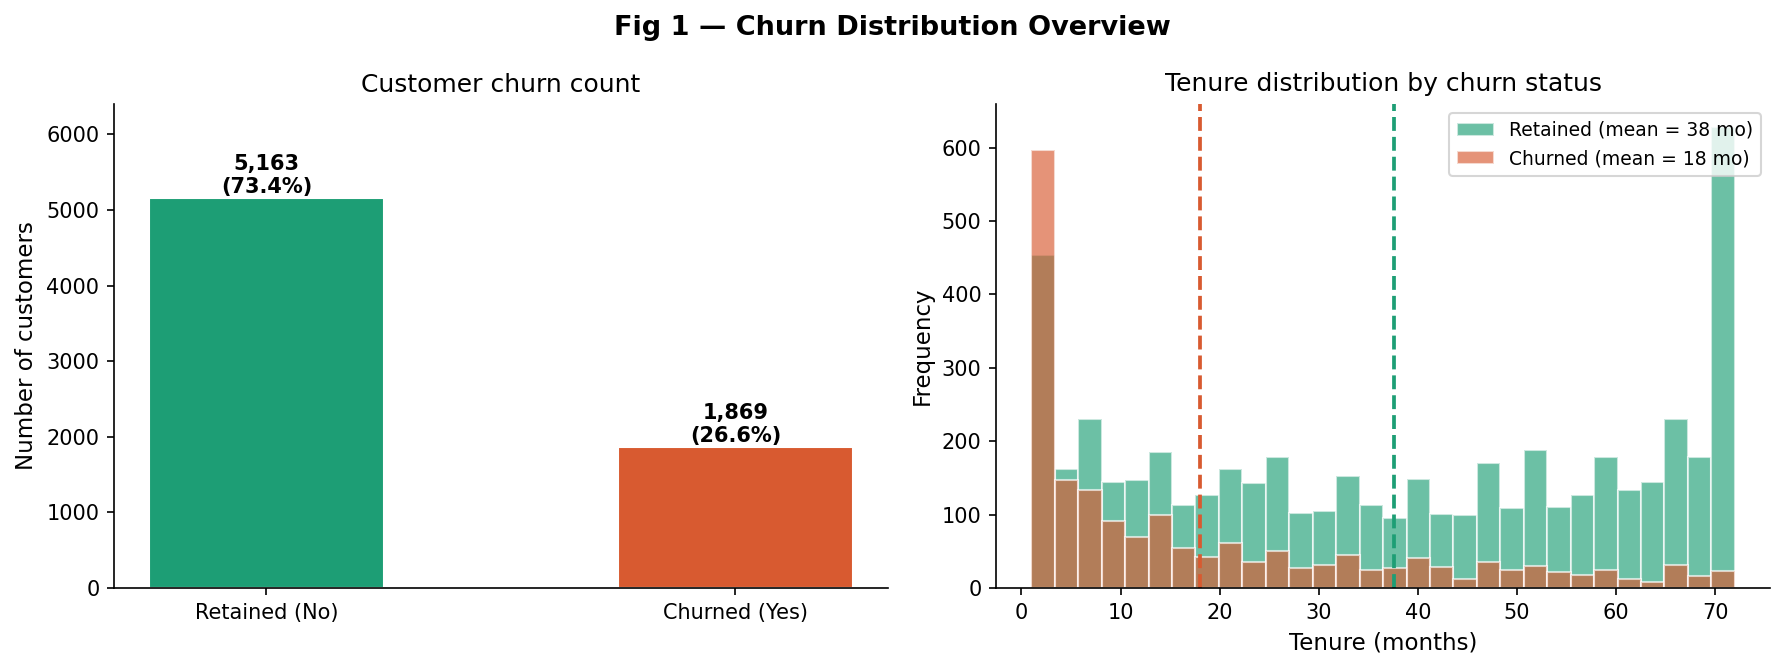

In [50]:
# Define colors
GREEN = '#1D9E75'
RED = '#D85A30'
AMBER = '#BA7517'
BLUE = '#185FA5'
GRAY = '#888780'

# ── Fig 1: Churn count + tenure histogram ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Fig 1 — Churn Distribution Overview', fontsize=13, fontweight='bold')
 
counts = df['Churn'].value_counts()
bars = axes[0].bar(['Retained (No)', 'Churned (Yes)'],
                   counts.values, color=[GREEN, RED], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{val:,}\n({val/len(df):.1%})',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Customer churn count')
axes[0].set_ylabel('Number of customers')
axes[0].set_ylim(0, 6400)
 
for g, c in [('No', GREEN), ('Yes', RED)]:
    mean_t = df[df['Churn']==g]['tenure'].mean()
    lbl    = 'Retained' if g == 'No' else 'Churned'
    axes[1].hist(df[df['Churn']==g]['tenure'], bins=30, alpha=0.65,
                 color=c, edgecolor='white', label=f'{lbl} (mean = {mean_t:.0f} mo)')
    axes[1].axvline(mean_t, color=c, linestyle='--', linewidth=1.8)
axes[1].set_title('Tenure distribution by churn status')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9)
 
plt.tight_layout()
plt.savefig('fig1_churn_overview.png', dpi=130, bbox_inches='tight')
plt.show()


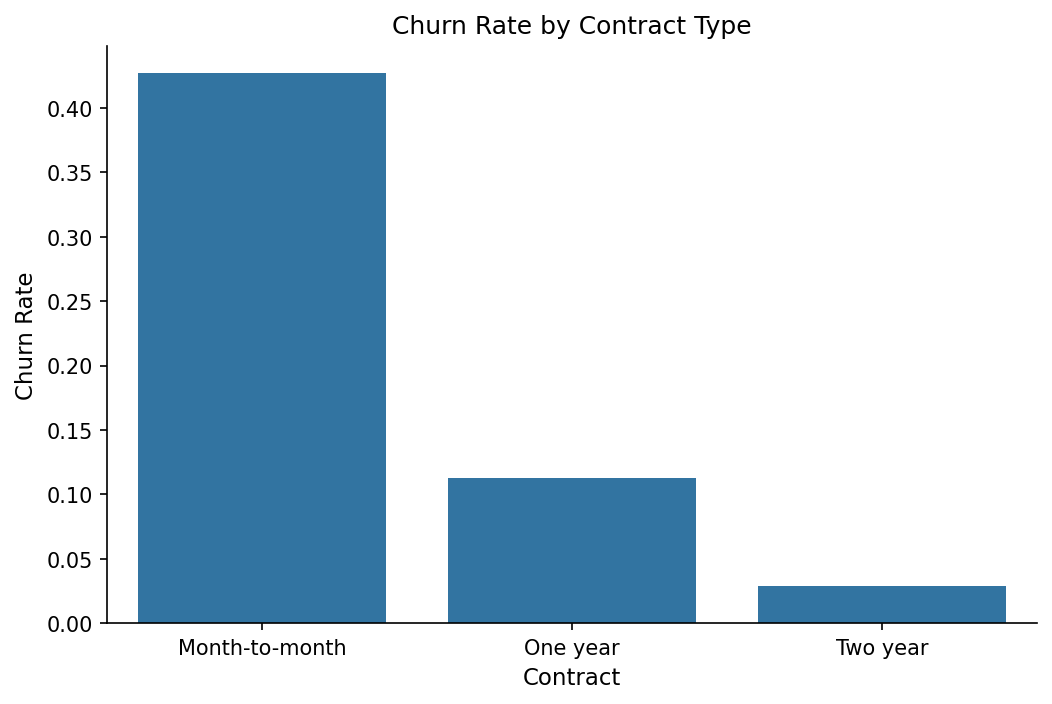

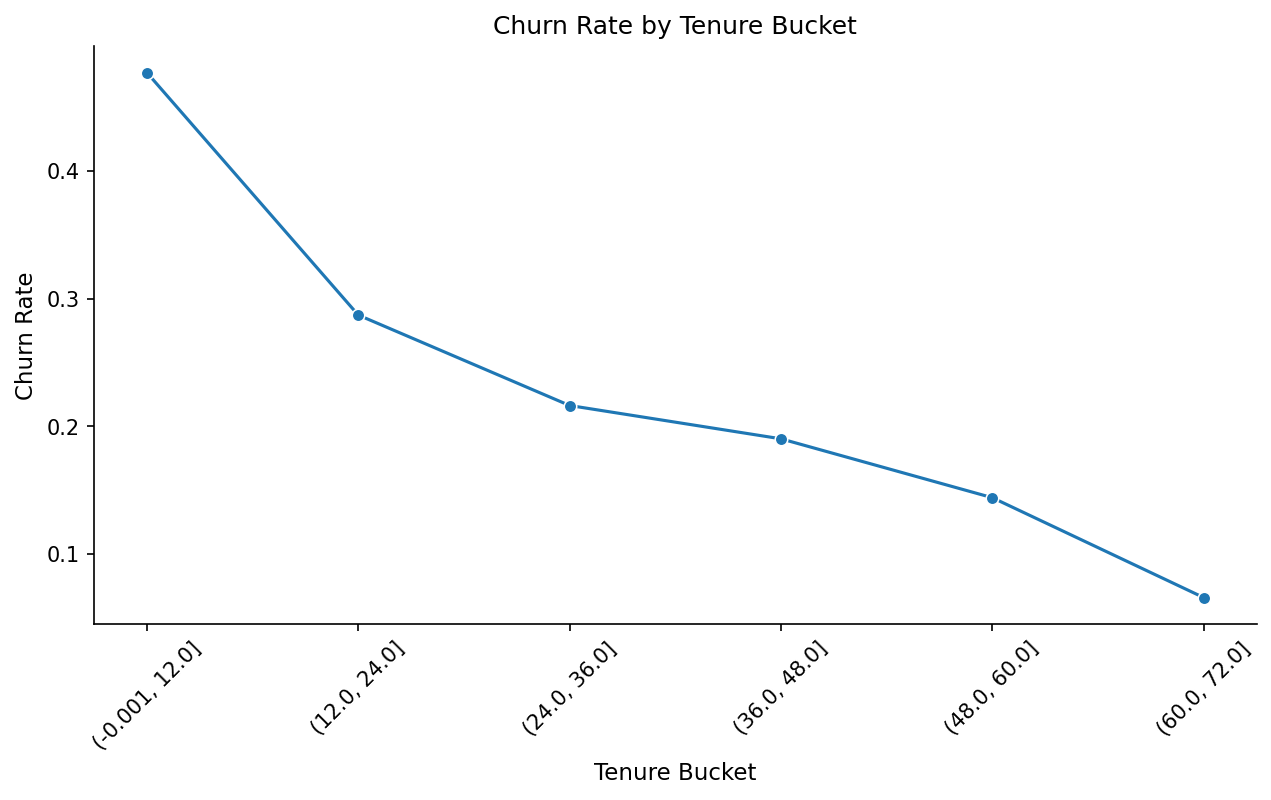

In [66]:
#Churn rate by contract
plt.figure(figsize=(8,5))
churn_by_contract = df.groupby('Contract', observed=True)['Churn_bin'].mean().reset_index()
sns.barplot(data=churn_by_contract, x="Contract", y="Churn_bin")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract")
plt.show()
# Churn by tenure buckets
df["tenure_bin"] = pd.cut(df["tenure"], bins=[0,12,24,36,48,60,72], include_lowest=True)
tenure_churn = df.groupby("tenure_bin")["Churn_bin"].mean().reset_index()
tenure_churn["tenure_bin"] = tenure_churn["tenure_bin"].astype(str)
tenure_churn

plt.figure(figsize=(10,5))
sns.lineplot(data=tenure_churn, x="tenure_bin", y="Churn_bin", marker="o")
plt.title("Churn Rate by Tenure Bucket")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Bucket")
plt.xticks(rotation=45)
plt.show()

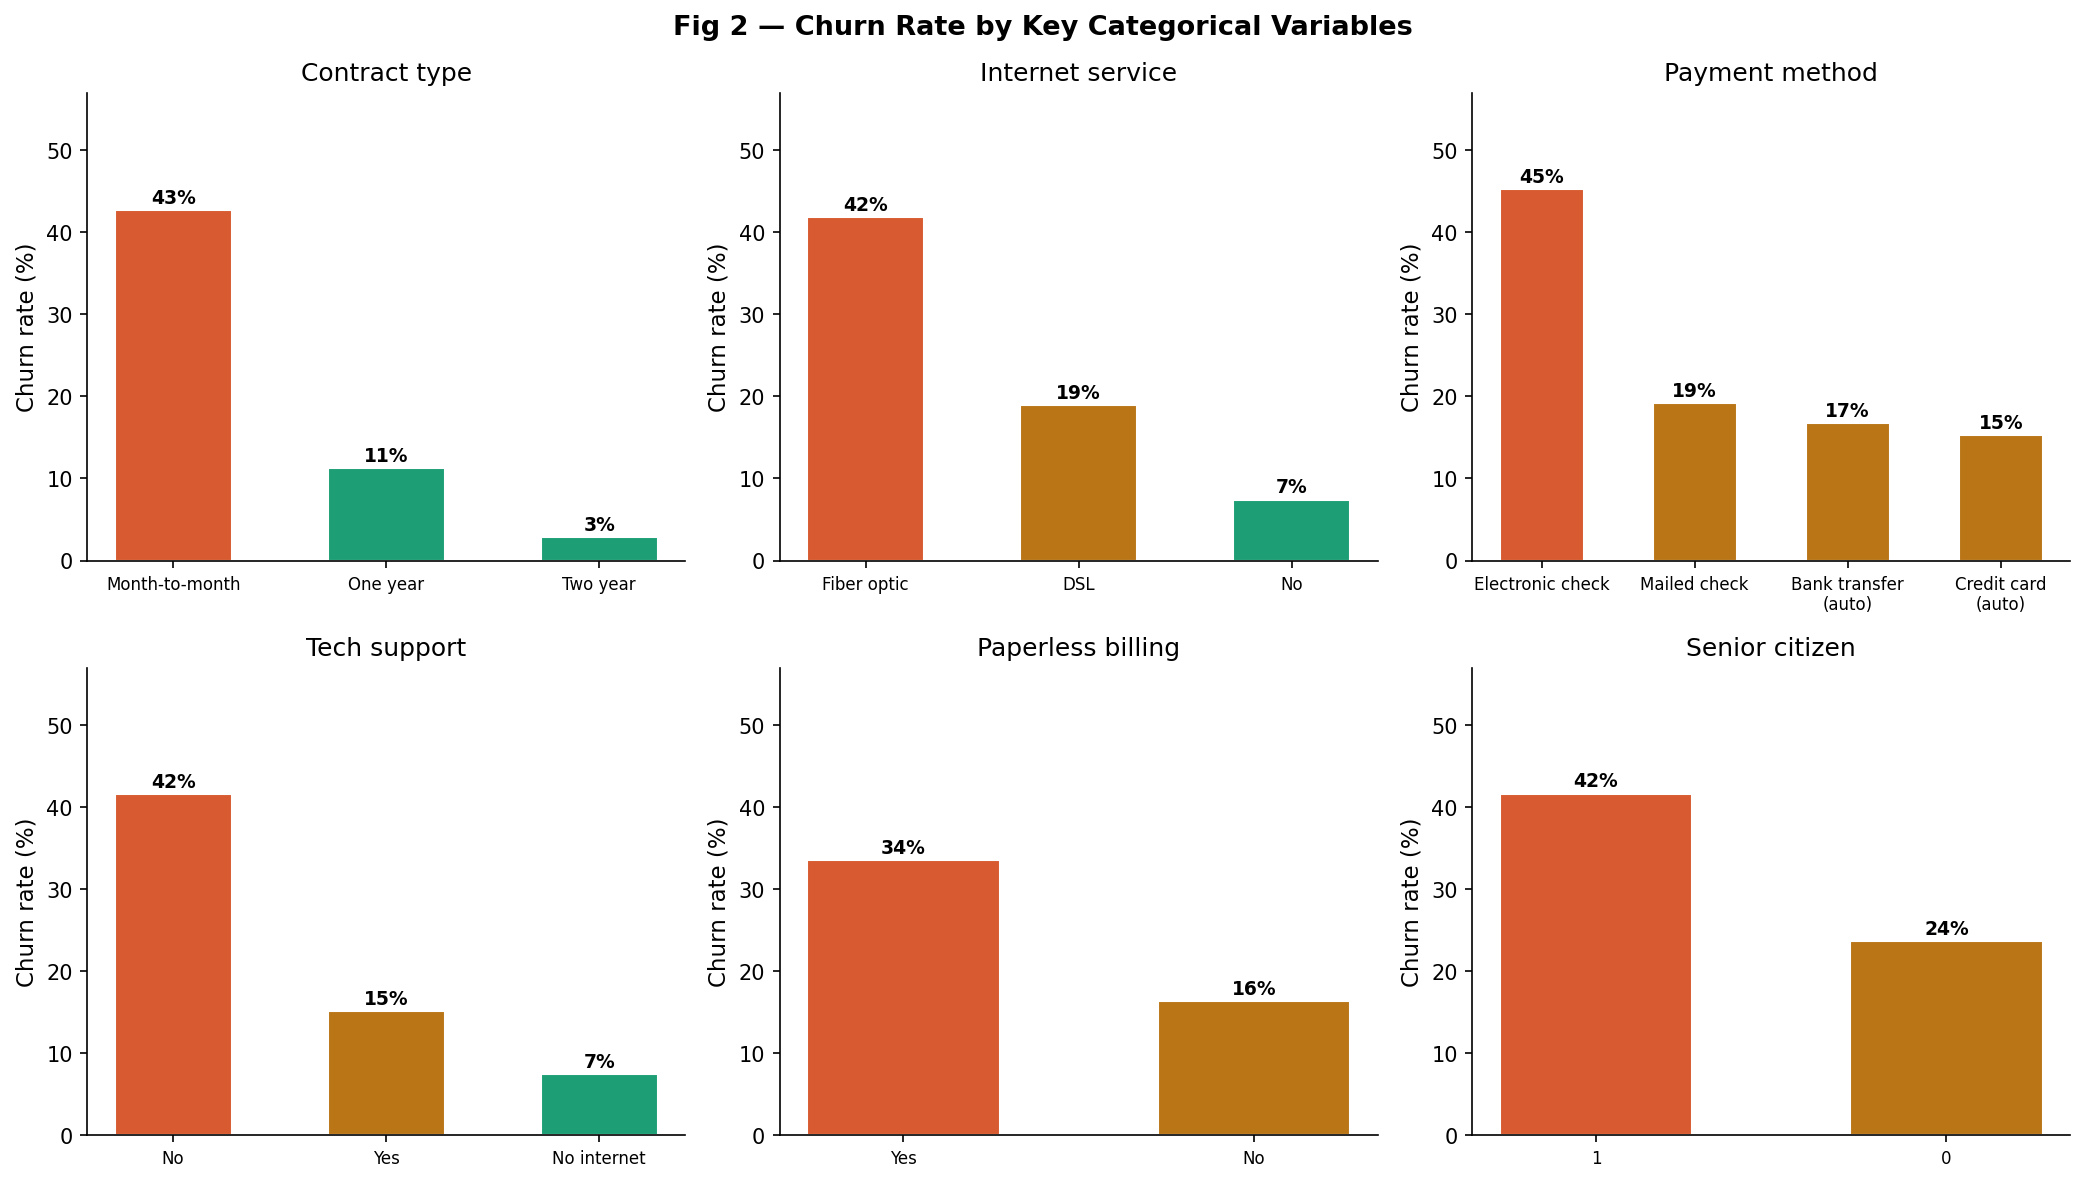

In [68]:
# ── Fig 2: Churn rate by categorical variables ──────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Fig 2 — Churn Rate by Key Categorical Variables',
             fontsize=13, fontweight='bold')
 
cats = [
    ('Contract',         'Contract type'),
    ('InternetService',  'Internet service'),
    ('PaymentMethod',    'Payment method'),
    ('TechSupport',      'Tech support'),
    ('PaperlessBilling', 'Paperless billing'),
    ('SeniorCitizen',    'Senior citizen'),
]
for ax, (col, title) in zip(axes.flatten(), cats):
    rates  = df.groupby(col)['Churn_bin'].mean().sort_values(ascending=False)
    labels = [str(l).replace(' (automatic)', '\n(auto)')
                    .replace('No internet service', 'No internet') for l in rates.index]
    colors = [RED if r > 0.3 else AMBER if r > 0.15 else GREEN for r in rates.values]
    bars   = ax.bar(labels, rates.values * 100, color=colors, edgecolor='white', width=0.55)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.8,
                f'{val:.0%}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel('Churn rate (%)')
    ax.set_ylim(0, 57)
    ax.tick_params(axis='x', labelsize=8)
 
plt.tight_layout()
plt.savefig('fig2_churn_by_category.png', dpi=130, bbox_inches='tight')
plt.show()

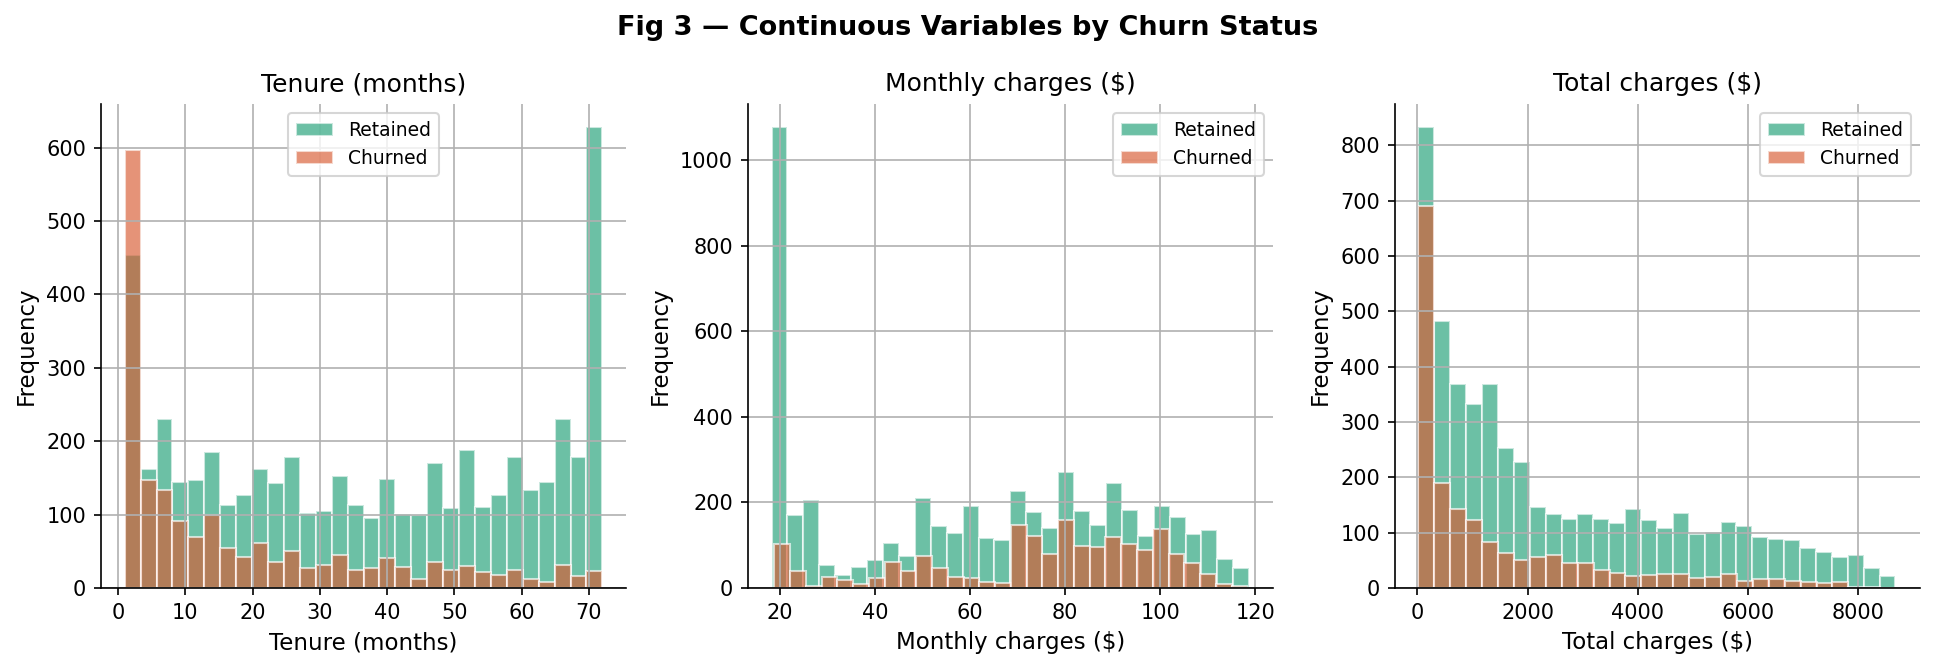

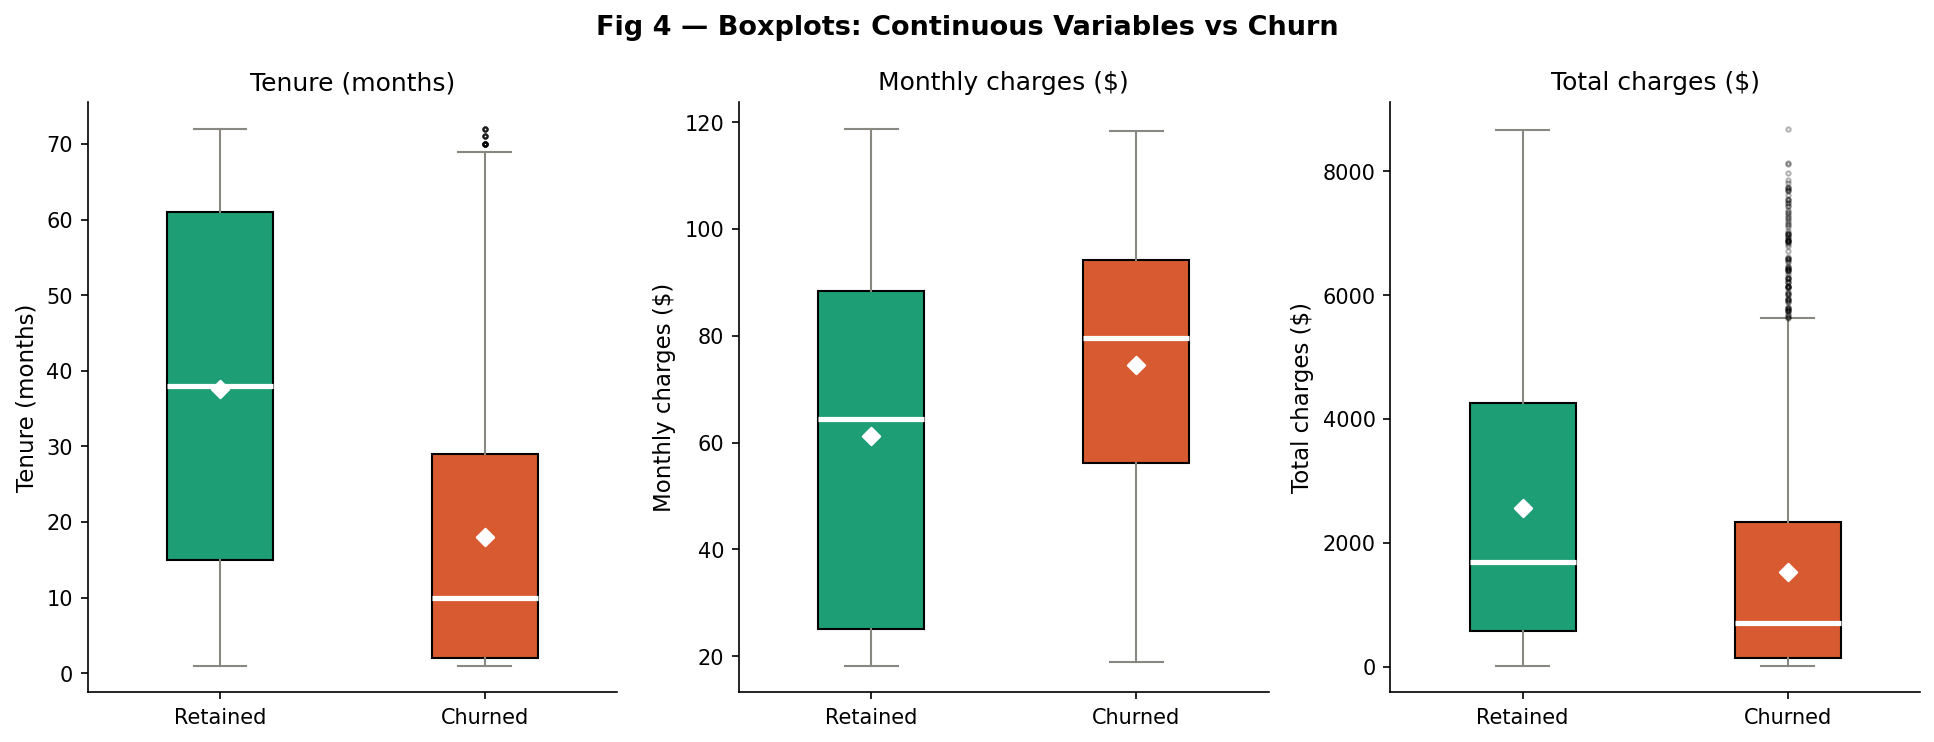

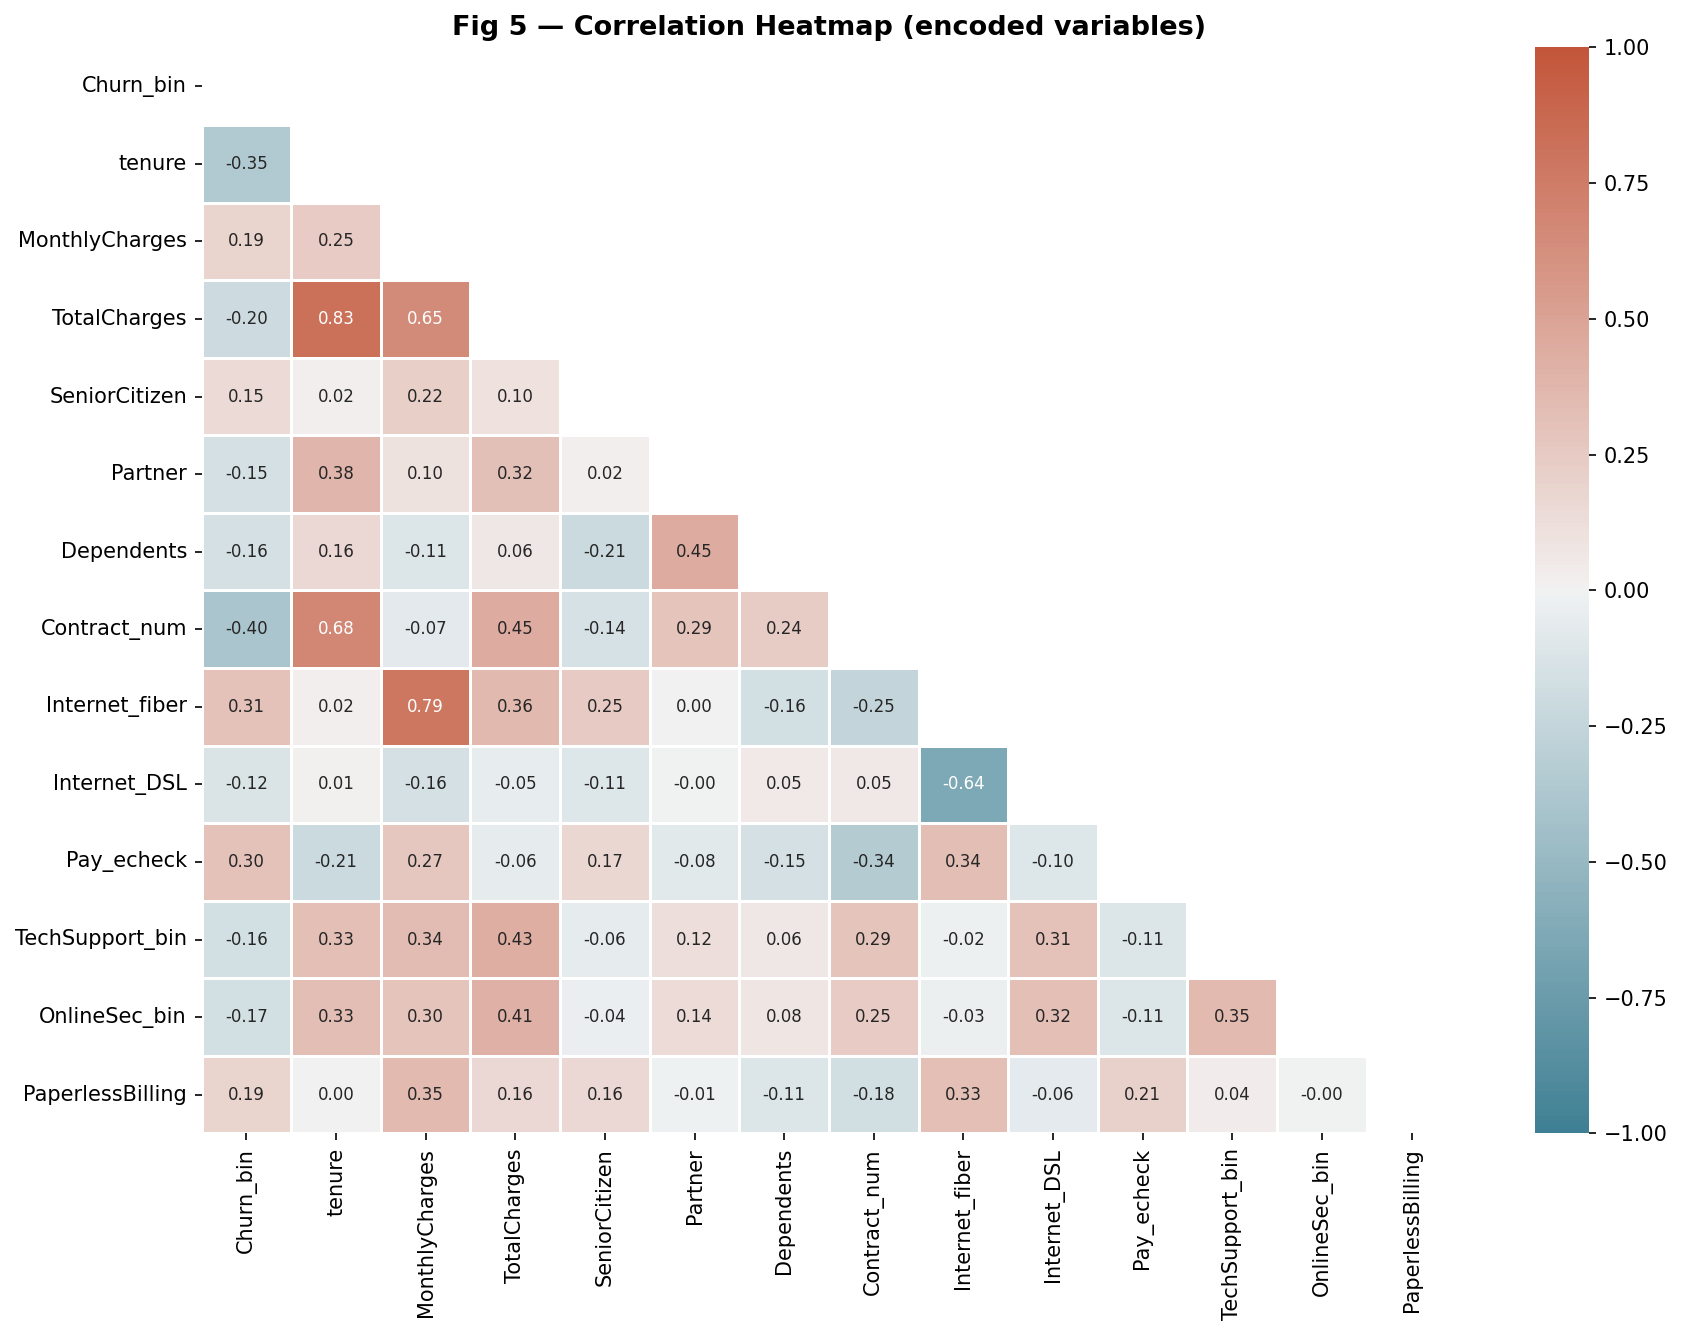

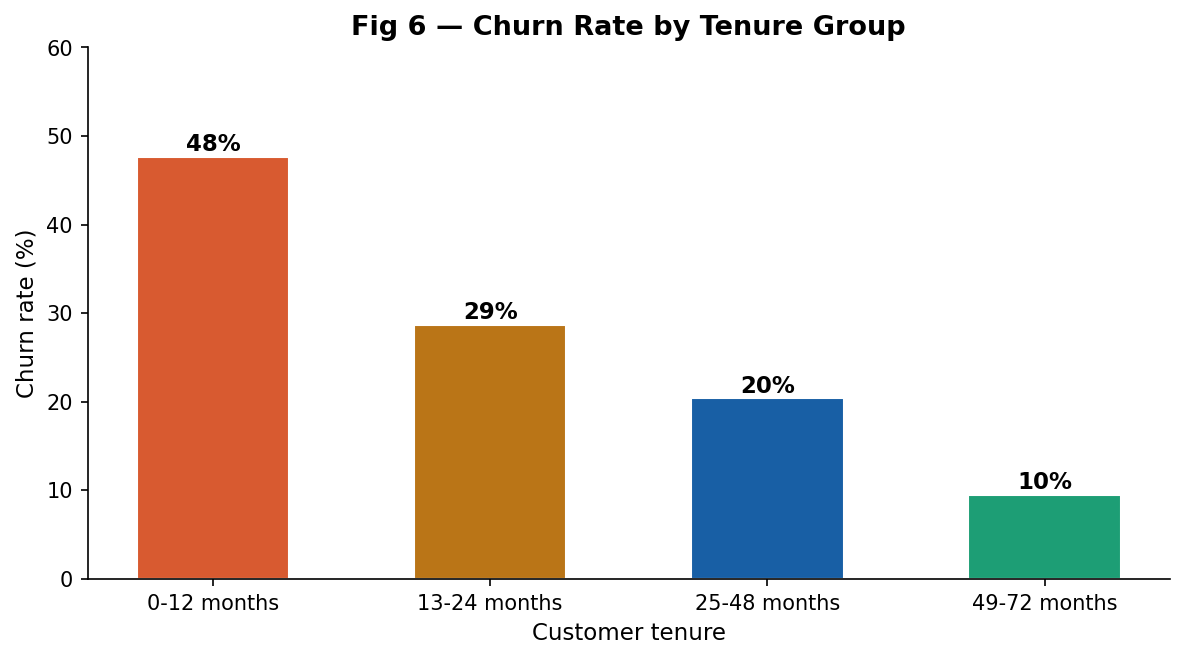

In [52]:
# ── Fig 3: Continuous variable histograms ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle('Fig 3 — Continuous Variables by Churn Status',
             fontsize=13, fontweight='bold')
 
for ax, col, title in zip(
    axes,
    ['tenure', 'MonthlyCharges', 'TotalCharges'],
    ['Tenure (months)', 'Monthly charges ($)', 'Total charges ($)']
):
    for g, c, lbl in [('No', GREEN, 'Retained'), ('Yes', RED, 'Churned')]:
        df[df['Churn']==g][col].dropna().hist(
            ax=ax, bins=30, alpha=0.65, color=c, label=lbl, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig('fig3_continuous_distributions.png', dpi=130, bbox_inches='tight')
plt.show()
 
# ── Fig 4: Boxplots ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Fig 4 — Boxplots: Continuous Variables vs Churn',
             fontsize=13, fontweight='bold')
 
for ax, col, title in zip(
    axes,
    ['tenure', 'MonthlyCharges', 'TotalCharges'],
    ['Tenure (months)', 'Monthly charges ($)', 'Total charges ($)']
):
    d_no  = df[df['Churn']=='No'][col].dropna()
    d_yes = df[df['Churn']=='Yes'][col].dropna()
    bp = ax.boxplot(
        [d_no, d_yes], patch_artist=True, widths=0.4,
        medianprops  = dict(color='white', linewidth=2.5),
        whiskerprops = dict(color=GRAY),
        capprops     = dict(color=GRAY),
        flierprops   = dict(marker='o', markersize=2, alpha=0.3, color=GRAY)
    )
    bp['boxes'][0].set_facecolor(GREEN)
    bp['boxes'][1].set_facecolor(RED)
    ax.set_xticklabels(['Retained', 'Churned'])
    ax.set_title(title)
    ax.set_ylabel(title)
    for i, d in enumerate([d_no, d_yes], 1):
        ax.scatter(i, d.mean(), marker='D', color='white', s=35, zorder=5)
 
plt.tight_layout()
plt.savefig('fig4_boxplots.png', dpi=130, bbox_inches='tight')
plt.show()
 
# ── Fig 5: Correlation heatmap ────────────────────────────────
df_enc = df.copy()
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'gender']:
    df_enc[col] = df_enc[col].map({'Yes':1, 'No':0, 'Male':1, 'Female':0})
df_enc['Contract_num']    = df_enc['Contract'].map(
    {'Month-to-month':0, 'One year':1, 'Two year':2})
df_enc['Internet_fiber']  = (df_enc['InternetService'] == 'Fiber optic').astype(int)
df_enc['Internet_DSL']    = (df_enc['InternetService'] == 'DSL').astype(int)
df_enc['Pay_echeck']      = (df_enc['PaymentMethod'] == 'Electronic check').astype(int)
df_enc['TechSupport_bin'] = (df_enc['TechSupport'] == 'Yes').astype(int)
df_enc['OnlineSec_bin']   = (df_enc['OnlineSecurity'] == 'Yes').astype(int)
 
hm_cols = [
    'Churn_bin', 'tenure', 'MonthlyCharges', 'TotalCharges',
    'SeniorCitizen', 'Partner', 'Dependents', 'Contract_num',
    'Internet_fiber', 'Internet_DSL', 'Pay_echeck',
    'TechSupport_bin', 'OnlineSec_bin', 'PaperlessBilling'
]
corr = df_enc[hm_cols].corr()
 
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8},
    vmin=-1, vmax=1
)
ax.set_title('Fig 5 — Correlation Heatmap (encoded variables)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
 
# ── Fig 6: Churn rate by tenure group ────────────────────────
df['tenure_group'] = pd.cut(
    df['tenure'], bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months']
)
tg = df.groupby('tenure_group', observed=True)['Churn_bin'].mean()
 
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(tg.index, tg.values * 100,
              color=[RED, AMBER, BLUE, GREEN], edgecolor='white', width=0.55)
for bar, val in zip(bars, tg.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.6,
            f'{val:.0%}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Fig 6 — Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Customer tenure')
ax.set_ylabel('Churn rate (%)')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.savefig('fig6_tenure_churn.png', dpi=130, bbox_inches='tight')
plt.show()

In [84]:
# ── B4. Hypotheses ───────────────────────────────────────────
print("""
── HYPOTHESES ──────────────────────────────────────────────────
 
H1: Longer customer tenure reduces the probability of churn .

H2: Higher monthly charges increase the probability of churn .

H3: Customers on one-year and two-year contracts are less likely to churn than customers on month-to-month contracts .
""")


── HYPOTHESES ──────────────────────────────────────────────────

H1: Longer customer tenure reduces the probability of churn .

H2: Higher monthly charges increase the probability of churn .

H3: Customers on one-year and two-year contracts are less likely to churn than customers on month-to-month contracts .



In [70]:
# SECTION D — ECONOMETRIC MODELS
print("  SECTION D — MODELS: LPM, LOGIT, INTERACTION TERMS")
df["Partner"] = df["Partner"].map({"Yes": 1, "No": 0})
df["Dependents"] = df["Dependents"].map({"Yes": 1, "No": 0})
df["PaperlessBilling_bin"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0})
df["OnlineSecurity_bin"] = df["OnlineSecurity"].replace({"Yes": 1, "No": 0, "No internet service": 0})
df["TechSupport_bin"] = df["TechSupport"].replace({"Yes": 1, "No": 0, "No internet service": 0})

  SECTION D — MODELS: LPM, LOGIT, INTERACTION TERMS


In [73]:
import statsmodels.formula.api as smf

# Linear probability model (LPM)
lpm_formula = """
Churn_bin ~ tenure + MonthlyCharges + TotalCharges + SeniorCitizen
+ C(Contract) + C(InternetService) + C(PaymentMethod)
+ C(gender) + Partner + Dependents + PaperlessBilling_bin
+ OnlineSecurity_bin + TechSupport_bin
+ tenure:MonthlyCharges + C(Contract):PaperlessBilling_bin
"""

lpm = smf.ols(lpm_formula, data=df).fit(cov_type="HC1")
print(lpm.summary())

                            OLS Regression Results                            
Dep. Variable:              Churn_bin   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.278
Method:                 Least Squares   F-statistic:                     166.5
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:14:58   Log-Likelihood:                -3078.9
No. Observations:                7032   AIC:                             6200.
Df Residuals:                    7011   BIC:                             6344.
Df Model:                          20                                         
Covariance Type:                  HC1                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [74]:
#Logit model
logit = smf.logit(lpm_formula, data=df).fit(disp=False)
print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:              Churn_bin   No. Observations:                 7032
Model:                          Logit   Df Residuals:                     7011
Method:                           MLE   Df Model:                           20
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.2778
Time:                        20:15:36   Log-Likelihood:                -2940.5
converged:                       True   LL-Null:                       -4071.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                                       -0.3522      0.224     -1.570      0.117      -0.792       0.088
C(Contract)[T.One year]      

In [82]:
# If needed, import metrics
%pip install scikit-learn
from sklearn.metrics import accuracy_score, confusion_matrix

3755.56s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 39.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Accuracy: 0.8030432309442548


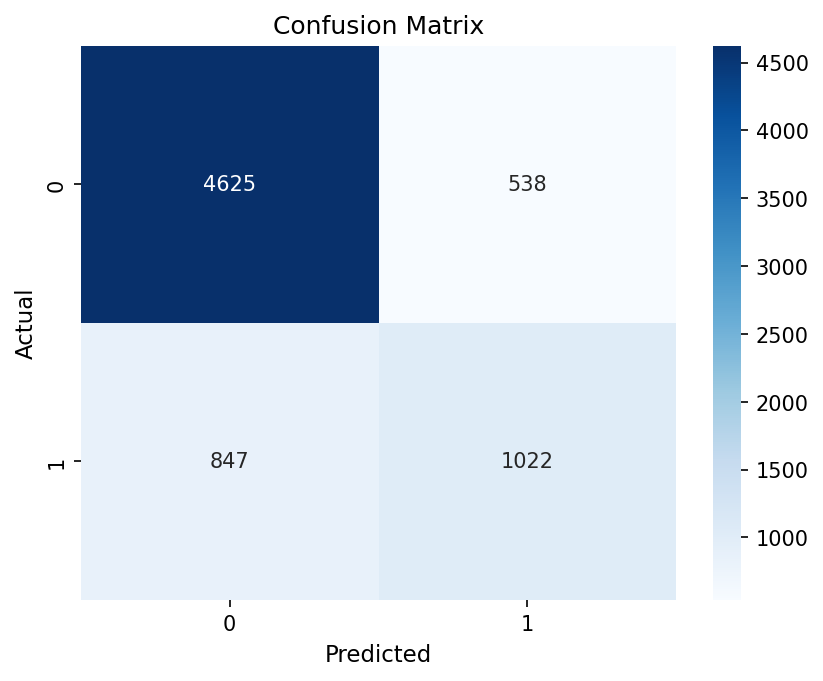

In [83]:
#Predicted churn probability
df["pred_churn_prob"] = logit.predict(df)
df[["Churn_bin", "pred_churn_prob"]].head()
#Classify customers as churn risk
df["pred_churn_class"] = (df["pred_churn_prob"] >= 0.5).astype(int)

# Accuracy
print("Accuracy:", accuracy_score(df["Churn_bin"], df["pred_churn_class"]))

#Confusion matrix
cm = confusion_matrix(df["Churn_bin"], df["pred_churn_class"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Save outputs
df.to_csv("telco_cleaned_for_analysis.csv", index=False)
# summary and missing must be defined elsewhere in your notebook
# summary.to_csv("summary_stats.csv")
# missing.to_csv("missing_values.csv")
pd.DataFrame({"LPM_coef": lpm.params, "LPM_pvalue": lpm.pvalues}).to_csv("lpm_results.csv")
pd.DataFrame({"Logit_coef": logit.params, "Logit_pvalue": logit.pvalues}).to_csv("logit_results.csv")